# Caregiver Survey Response Review

Two studies fed this review.

- **Study 1, the verified caregiver sample.** 177 people we know are real caregivers. This is the control group.
- **Study 2, the online recruitment sample.** 1,779 sign-ups that we have to decide whether to pay.

Every response answered the same four sections: **Family Information**, **Values**, **Thoughts, Feelings, and Attitudes**, and **Demographics**.

This notebook answers four questions in order.

1. What is the rule, and where did every number in it come from?
2. What did a flagged response actually answer, next to what a real caregiver actually answered?
3. Do those patterns hold across all 1,956 responses?
4. What does the rule produce, and what does it miss?

In [1]:
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

import bot_analysis as ba

ba = importlib.reload(ba)

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 90)

project_dir = Path.cwd()
output_dir = project_dir / "Caregiver Outputs"
cache_dir = project_dir / "data_cache"

# Every table and chart below is built from the saved study outputs and the
# cached survey answers. Nothing is typed in by hand.
views = ba.build_notebook_views(output_dir, cache_dir)
report_records = views["report_records"]
action_summary = ba.build_workbook_action_summary(report_records)
timing_summary = ba.build_workbook_timing_summary(report_records)
study_action_summary = views["study_action_summary"]
hold_pile_mix = views["flag_strength_summary"]

# One record-level table sits behind every view in this notebook.
screen_inputs = ba.build_screen_inputs(output_dir, cache_dir)

print(f"Responses loaded: {len(screen_inputs):,}")
print(screen_inputs["Group"].value_counts().to_string())

Responses loaded: 1,956
Group
Online sign-ups           1779
Caregivers we verified     177


---
# 1. The rule and where its numbers came from

## 1.1 The rule in one line

A response is held when it crosses **one strong line on its own**, or when **two milder patterns appear together**.

Write $S$ for the number of strong patterns found on a response and $M$ for the number of milder ones.

$$
\text{Decision} =
\begin{cases}
\textbf{Hold for review} & \text{if } S \ge 1 \text{ or } M \ge 2 \\[4pt]
\textbf{Quick check, then pay} & \text{if } S = 0 \text{ and } M = 1 \\[4pt]
\textbf{Pay now} & \text{if } S = 0 \text{ and } M = 0
\end{cases}
$$

The table below lists which patterns count as strong, which count as milder, and where in the survey each one comes from.

In [2]:
display(ba.build_decision_rule_table())

,What we look for,Where it appears,How seriously we treat it,How it affects payment
0,Whole survey too fast,Whole survey timing,Serious,Any one of these on its own moves the response to review
1,"Thoughts, Feelings, and Attitudes section too fast","Thoughts, Feelings, and Attitudes timing",Serious,Any one of these on its own moves the response to review
2,Answer sheet identical to another response,Full answer pattern across the questionnaire,Serious,Any one of these on its own moves the response to review
3,Family answers contradict each other,Family Information,Serious,Any one of these on its own moves the response to review
4,Age and location cannot both be true,Demographics,Serious,Any one of these on its own moves the response to review
5,One section rushed,"Section timing across Family Information, Values, Thoughts/Feelings/Attitudes, or Demo...",Supporting,Two or more of these together move the response to review
6,Same answer repeated down a block,Repeated ratings within a survey block,Supporting,Two or more of these together move the response to review
7,Arrived within a minute of two or more others,Response arrival time,Supporting,Two or more of these together move the response to review
8,Comment nearly identical to another,Open-text comment,Supporting,Two or more of these together move the response to review


## 1.2 Where each line was drawn

None of these numbers were chosen after looking at Study 2. Each one was read off the **131 verified caregivers who finished all four sections**.

Two kinds of line are used.

**Smallest observed value.** For the whole survey and for the attitudes section, the line is the fastest verified caregiver:

$$L = \min\bigl(t_1, t_2, \dots, t_{131}\bigr)$$

**1st percentile.** For the individual sections and the repeated-answer check, the line is the value that only the most extreme 1 in 100 verified caregivers fall below:

$$L = Q_{0.01}\bigl(t_1, t_2, \dots, t_{131}\bigr)$$

One line is different, and the table says so: the burst window was **not** read off the verified caregivers.

In [3]:
display(ba.build_limit_origin_table(output_dir))

,What we check,The line we drew,How that line was worked out,Whose answers set it
0,Whole survey too fast,11 minutes 34 seconds,Smallest whole-survey time among the verified caregivers,The 131 verified caregivers who finished every section
1,"Thoughts, Feelings, and Attitudes section too fast",7 minutes 51 seconds,Smallest section time among the verified caregivers,The 131 verified caregivers who finished every section
2,Family Information section rushed,47 seconds,1st percentile of verified caregiver times on that section,The 131 verified caregivers who finished every section
3,Values section rushed,41 seconds,1st percentile of verified caregiver times on that section,The 131 verified caregivers who finished every section
4,Attitudes section rushed,8 minutes 34 seconds,1st percentile of verified caregiver times on that section,The 131 verified caregivers who finished every section
5,Demographics section rushed,1 minute 6 seconds,1st percentile of verified caregiver times on that section,The 131 verified caregivers who finished every section
6,Same answer repeated down a rating block,"Answers spread by 0.78 to 1.11 points or less, depending on the block","1st percentile of the verified caregivers' answer spread, worked out separately for ea...",The 131 verified caregivers who finished every section
7,Arrived within a minute of two or more others,3 or more sign-ups inside 60 seconds,"The verified caregivers' 1st percentile gap was 3 seconds, which was too tight to be u...",The 131 verified caregivers who finished every section


## 1.3 Checking the arithmetic

The lines above live in a saved file. The cell below ignores that file, goes back to the raw survey answers, redoes both calculations, and prints the two numbers next to each other.

If any row said **No**, the report and the raw data would disagree.

In [4]:
threshold_check = ba.build_threshold_check_table(output_dir, cache_dir)
display(threshold_check)
print(f"Recomputed from the {threshold_check.attrs['verified_n']} verified caregivers "
      f"who finished all four sections.")

,What we check,How the line is worked out,Line used in the report (minutes),Line recomputed here (minutes),Do they match
0,Whole survey too fast,smallest whole-survey time,11.570,11.570,Yes
1,Attitudes section too fast,smallest attitudes time,7.850,7.850,Yes
2,Family Information section rushed,1st percentile of verified times,0.786,0.786,Yes
3,Values section rushed,1st percentile of verified times,0.680,0.680,Yes
4,Attitudes section rushed,1st percentile of verified times,8.568,8.568,Yes
5,Demographics section rushed,1st percentile of verified times,1.100,1.100,Yes


Recomputed from the 131 verified caregivers who finished all four sections.


---
# 2. What the responses actually answered

Charts about 1,779 responses are easy to argue with. Two real responses side by side are not.

Both examples below are picked by rule, not by hand:

- The **verified caregiver** is the one closest to the middle of the verified group on whole-survey time, among those who answered every question shown.
- The **online sign-up** is the clearest case of the pattern being explained.

## 2.1 The repeated-answer check, on real answers

Both responses below were asked the same eleven questions, all on the same 1 to 5 scale.

,Question in this block,Online sign-up 296 answered,Verified caregiver 114 answered
0,Angry,2,1
1,Comfortable,2,5
2,Disgusted,2,1
3,How sure the test would need to be,2,1
4,Happy,2,4
5,Odds a younger sibling is also autistic,2,5
6,Sad,2,1
7,Scared,2,1
8,Surprised,2,3
9,When you would want the test done,2,5


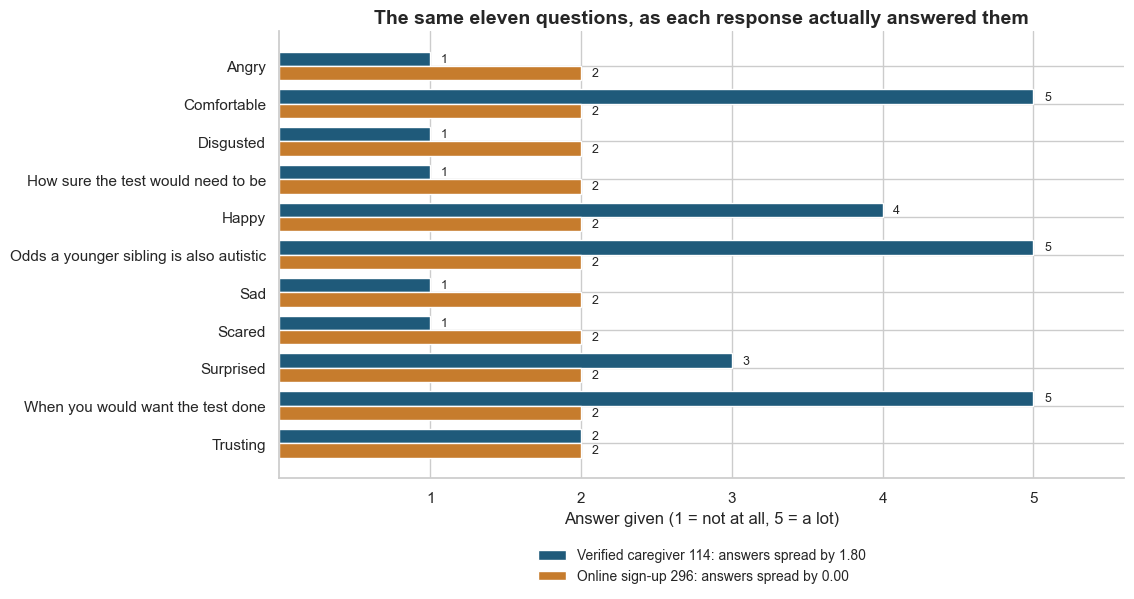

In [5]:
answer_comparison = ba.build_answer_comparison(screen_inputs, cache_dir)
display(answer_comparison)
ba.plot_answer_comparison(answer_comparison);

### The arithmetic behind that check

"Answers repeated down a block" is measured as the **spread** of the answers, which is their standard deviation. For $n$ answers $x_1 \dots x_n$ with average $\bar{x}$:

$$
\text{spread} \;=\; \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - 1}}
$$

If every answer is the same, each gap $x_i - \bar{x}$ is zero, so the spread is exactly **0.00**.

The line for this block is **0.82**, which is the 1st percentile of the verified caregivers' spread. The cell below runs the formula on both responses, step by step.

In [6]:
flagged_id = answer_comparison.attrs["flagged_id"]
verified_id = answer_comparison.attrs["verified_id"]
limit = answer_comparison.attrs["limit"]

for who, column in [
    (f"Online sign-up {flagged_id}", f"Online sign-up {flagged_id} answered"),
    (f"Verified caregiver {verified_id}", f"Verified caregiver {verified_id} answered"),
]:
    answers = answer_comparison[column].astype(float)
    n = len(answers)
    average = answers.mean()
    squared_gaps = ((answers - average) ** 2).sum()
    spread = (squared_gaps / (n - 1)) ** 0.5
    verdict = "at or below the line, so this counts as repeated answers" if spread <= limit \
        else "above the line, so this does not count"

    print(who)
    print(f"  the {n} answers      : {[int(v) for v in answers]}")
    print(f"  average answer       : {average:.4f}")
    print(f"  sum of squared gaps  : {squared_gaps:.4f}")
    print(f"  spread               : sqrt({squared_gaps:.4f} / {n - 1}) = {spread:.4f}")
    print(f"  against the line 0.82: {verdict}")
    print()

Online sign-up 296
  the 11 answers      : [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  average answer       : 2.0000
  sum of squared gaps  : 0.0000
  spread               : sqrt(0.0000 / 10) = 0.0000
  against the line 0.82: at or below the line, so this counts as repeated answers

Verified caregiver 114
  the 11 answers      : [1, 5, 1, 1, 4, 5, 1, 1, 3, 5, 2]
  average answer       : 2.6364
  sum of squared gaps  : 32.5455
  spread               : sqrt(32.5455 / 10) = 1.8040
  against the line 0.82: above the line, so this does not count



## 2.2 The timing checks, on real section times

Same idea, applied to how long each section took. Response 1026 is one of the six responses the study marked as a confirmed bot.

A section counts as rushed when its time falls below that section's line:

$$t_{\text{section}} < L_{\text{section}}$$

,Survey section,Online sign-up 1026 (minutes),Verified caregiver 114 (minutes),Rushed-section line (minutes),Was this section rushed
0,Family Information,0.85,3.93,0.79,No
1,Values,0.10,2.68,0.68,Yes
2,"Thoughts, Feelings, and Attitudes",2.47,17.72,8.57,Yes
3,Demographics,0.75,2.53,1.10,Yes
4,Whole survey,4.17,26.86,11.57,Yes


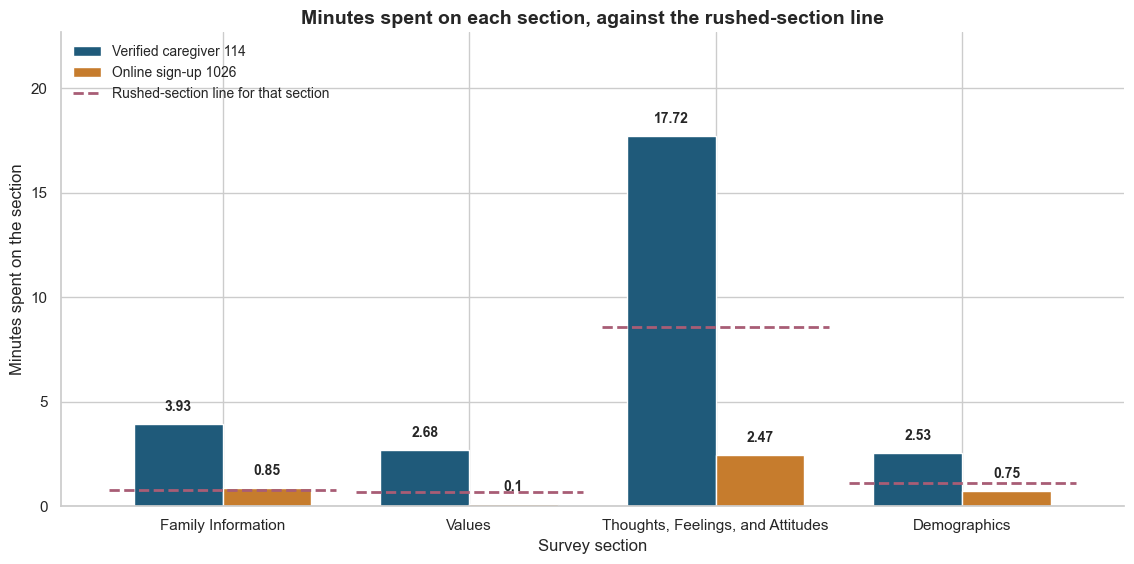

In [7]:
section_comparison = ba.build_section_time_comparison(screen_inputs, output_dir, cache_dir)
display(section_comparison)
ba.plot_section_time_comparison(section_comparison);

## 2.3 The Family Information check, on real answers

This check needs no timing and no statistics. It reads two answers from the same page and asks whether they can both be true.

A response says how many children it has, then ticks the age bands those children fall into. One child belongs to exactly one age band, so:

$$\text{age bands ticked} \;\le\; \text{children reported}$$

When that fails, the two answers contradict each other.

In [8]:
display(ba.build_family_contradiction_example(output_dir, cache_dir))

,Response,Children reported,Age bands ticked,Which age bands,Why this cannot be true
0,1069,2,3,"3 to 5 years, 6 to 10 years, 11 to 14 years","3 age bands need at least 3 children, but the response reported 2"
1,120,2,3,"Under 1 year, 11 to 14 years, 15 to 17 years","3 age bands need at least 3 children, but the response reported 2"
2,167,2,3,"1 to 2 years, 6 to 10 years, 11 to 14 years","3 age bands need at least 3 children, but the response reported 2"
3,1774,1,2,"11 to 14 years, 15 to 17 years","2 age bands need at least 2 children, but the response reported 1"


## 2.4 Six responses from start to finishFive online sign-ups, plus one verified caregiver on the first row so the other five have something to be read against. The five online sign-ups run from no concerns at all through to the strongest concern.Read across each row: what the response said about its family, how it answered the ratings, how long it took, and what that produced.

In [9]:
display(ba.build_worked_examples(screen_inputs, output_dir=output_dir, cache_dir=cache_dir))

,Response,Family Information,"Thoughts, Feelings, and Attitudes",Timing and arrival,Why this response landed here,Decision
0,114 (verified caregiver),2 children; 1 autistic child; pregnancy item marked no; Family Information answers lin...,"Example item ratings: happy=4, scared=1, difficult=4, doable=1; answers moved across t...",Whole survey 26m 52s; Thoughts/Feelings/Attitudes 17m 43s,"This is the control row. It is a caregiver we verified, so it shows what the same four...",Cleared for payment now
1,1779,2 children; 0 autistic children; pregnancy item marked no; Family Information answers ...,"Example item ratings: happy=4, scared=3, difficult=4, doable=1; answers moved across t...",Whole survey 35m 32s; Thoughts/Feelings/Attitudes 28m 24s,"Nothing in the timings or answer pattern stood out, so this response stays in the pay-...",Cleared for payment now
2,1243,1 child; 1 autistic child; pregnancy item marked no; Family Information answers lined up.,"Example item ratings: happy=3, scared=4, difficult=3, doable=2; answers moved across t...",Whole survey 30m 50s; Thoughts/Feelings/Attitudes 21m 17s; Arrived inside a 1-minute c...,"Only one milder pattern showed up, so this response needs just a quick check before pa...",Low-risk provisional approval
3,1276,1 child; 1 autistic child; pregnancy item marked no; Family Information answers lined up.,"Example item ratings: happy=4, scared=4, difficult=3, doable=2; answers moved across t...",Whole survey 21m 14s; Thoughts/Feelings/Attitudes 16m 17s; Section below the verified-...,"2 milder patterns showed up together, so this response is held for review.",Needs human review
4,1355,2 children; 0 autistic children; pregnancy item marked no; Family Information answers ...,"Example item ratings: happy=5, scared=2, difficult=3, doable=2; answers moved across t...",Whole survey 10m 50s; Thoughts/Feelings/Attitudes 7m 41s; Section below the verified-c...,"2 strong patterns and 2 supporting patterns showed up, so this response is held for re...",Needs human review
5,1026,1 child; 1 autistic child; pregnancy item marked yes; Marked prenatal screening as yes...,"Example item ratings: happy=3, scared=5, difficult=2, doable=2; answers changed very l...",Whole survey 4m 10s; Thoughts/Feelings/Attitudes 2m 28s; Section below the verified-ca...,Very fast timing plus answer-pattern or Family Information problems put this response ...,Confirmed bot / reject


---
# 3. Does this hold across all the responses?

## 3.1 Timing

Blue bars are the verified caregiver sample. Orange bars are the online recruitment sample. Bars sit side by side, never on top of one another, so each group's height can be read directly.

The shaded area is the region the rule treats as too fast. No blue bar sits fully inside it, because the line was placed at the fastest verified caregiver.

,Group,Responses we could time,Middle time (minutes),Fastest time (minutes),Faster than the line
0,Caregivers we verified - whole survey,131,26.69,11.57,0 of 131
1,Online sign-ups - whole survey,"1,575",20.87,3.80,"283 of 1,575"
2,"Caregivers we verified - Thoughts, Feelings, and Attitudes section",131,18.93,7.85,0 of 131
3,"Online sign-ups - Thoughts, Feelings, and Attitudes section","1,587",12.22,2.05,"447 of 1,587"


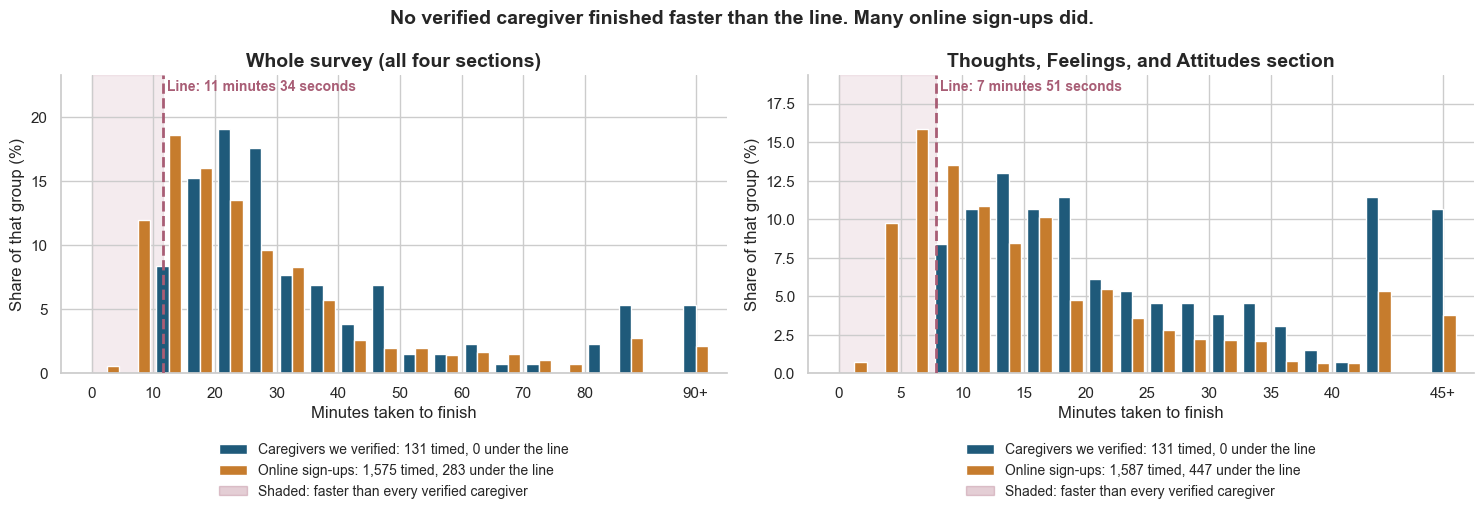

In [10]:
display(ba.build_speed_reference_table(screen_inputs))
ba.plot_speed_comparison(screen_inputs);

## 3.2 What happens if the attitudes line moves

Loosening the line catches more online sign-ups but starts catching verified caregivers too. The chart shows where that trade begins.

Read the two panels together: the top panel is what a line would catch, the bottom is who it would catch wrongly.

,Where we draw the line,"Online sign-ups caught (of 1,587)",Verified caregivers caught by mistake (of 131),What this setting means
0,4 minutes,80,0,"Catches no verified caregiver, but holds fewer online sign-ups"
1,5 minutes,167,0,"Catches no verified caregiver, but holds fewer online sign-ups"
2,6 minutes,260,0,"Catches no verified caregiver, but holds fewer online sign-ups"
3,7 minutes,375,0,"Catches no verified caregiver, but holds fewer online sign-ups"
4,7.85 minutes (today's setting),447,0,"Today's setting, and the loosest line that still catches no verified caregiver"
5,9 minutes,543,4,Pulls 4 verified caregiver(s) into the hold pile
6,10 minutes,633,11,Pulls 11 verified caregiver(s) into the hold pile
7,12 minutes,774,24,Pulls 24 verified caregiver(s) into the hold pile
8,15 minutes,939,42,Pulls 42 verified caregiver(s) into the hold pile


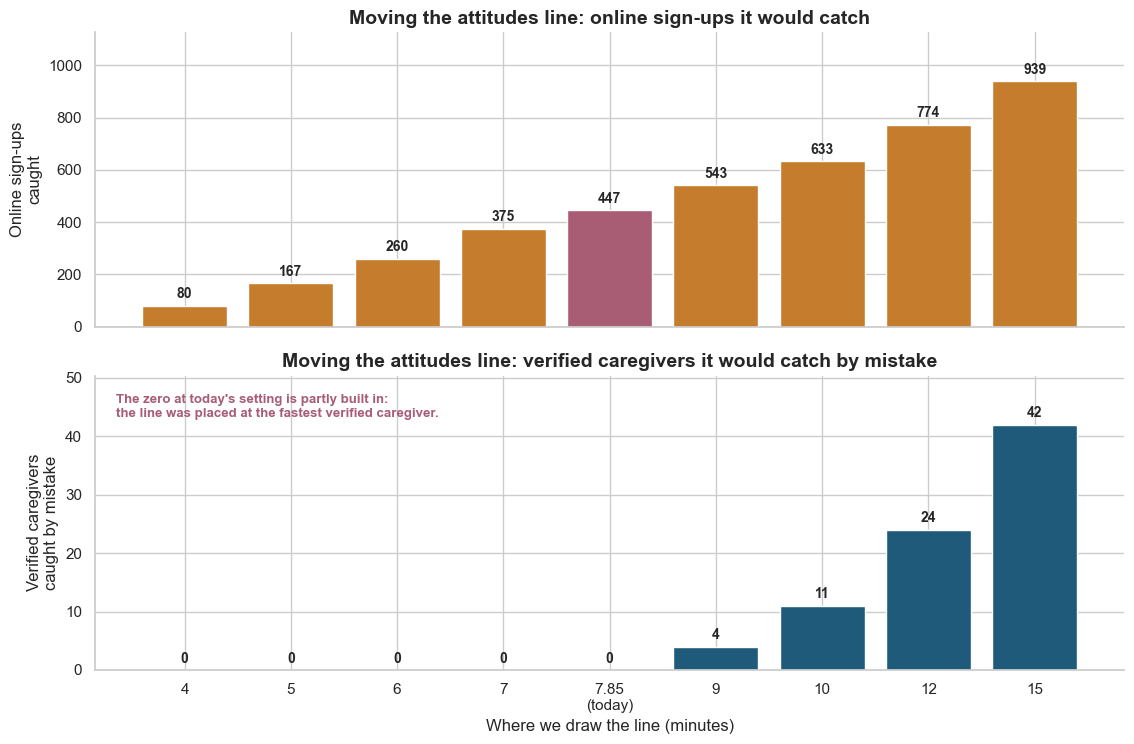

In [11]:
cutoff_sensitivity = ba.build_cutoff_sensitivity_table(screen_inputs)
display(cutoff_sensitivity)
ba.plot_cutoff_sensitivity(cutoff_sensitivity);

## 3.3 How often each check fires on people we know are real

This is the false alarm check. The count of verified caregivers each check could fire on changes by row, and the table says why: the two whole-timing checks can only fire on the 131 responses that were timed end to end.

The row to watch is **Age and location cannot both be true**. It has fired only in the verified sample and never in the online sample, so it works better as a review cue than as a reason to refuse payment.

In [12]:
display(ba.build_wrong_flag_table(screen_inputs))

,Pattern we look for,Where it shows up,How seriously we treat it,Verified caregivers this check could fire on,Verified caregivers it fired on,What that tells us,How to use it
0,Same answer repeated down a block,Repeated ratings within a survey block,Supporting,177,12,This pattern showed up in 12 of 177 people we know are real.,"Use it to sort the queue, never on its own"
1,One section rushed,"Section timing across Family Information, Values, Thoughts/Feelings/Attitudes, or Demo...",Supporting,177,7,This pattern showed up in 7 of 177 people we know are real.,"Use it to sort the queue, never on its own"
2,Arrived within a minute of two or more others,Response arrival time,Supporting,177,6,This pattern showed up in 6 of 177 people we know are real.,"Use it to sort the queue, never on its own"
3,Age and location cannot both be true,Demographics,Serious,177,2,This pattern showed up in 2 of 177 people we know are real.,"Review this check. It has never fired on an online sign-up, only on people we know are..."
4,Whole survey too fast,Whole survey timing,Serious,131,0,"Zero here is partly built in: this line was placed at the fastest verified caregiver, ...",Strong enough to act on with a quick spot check
5,"Thoughts, Feelings, and Attitudes section too fast","Thoughts, Feelings, and Attitudes timing",Serious,131,0,"Zero here is partly built in: this line was placed at the fastest verified caregiver, ...",Strong enough to act on with a quick spot check
6,Answer sheet identical to another response,Full answer pattern across the questionnaire,Serious,177,0,This pattern has not shown up in either study.,Strong enough to act on with a quick spot check
7,Family answers contradict each other,Family Information,Serious,177,0,"It never fired on a verified caregiver, and it fired on 44 online sign-ups.",Strong enough to act on with a quick spot check
8,Comment nearly identical to another,Open-text comment,Supporting,177,0,"It never fired on a verified caregiver, and it fired on 17 online sign-ups.",Strong enough to act on with a quick spot check


## 3.4 How often each pattern showed up in each group

Counts alone cannot be compared here, because the online sample is ten times larger. The chart uses shares so both groups sit on one scale, and the gap between each pair of bars is the evidence.

,Pattern,Where it shows up,How seriously we treat it,"Online sign-ups showing it (of 1,779)",Share of online sign-ups (%),Verified caregivers showing it (of 177),Share of verified caregivers (%)
0,Arrived within a minute of two or more others,Response arrival time,Supporting,1676,94.2,6,3.4
1,One section rushed,"Section timing across Family Information, Values, Thoughts/Feelings/Attitudes, or Demo...",Supporting,839,47.2,7,4.0
2,Same answer repeated down a block,Repeated ratings within a survey block,Supporting,577,32.4,12,6.8
3,"Thoughts, Feelings, and Attitudes section too fast","Thoughts, Feelings, and Attitudes timing",Serious,447,25.1,0,0.0
4,Whole survey too fast,Whole survey timing,Serious,283,15.9,0,0.0
5,Family answers contradict each other,Family Information,Serious,44,2.5,0,0.0
6,Comment nearly identical to another,Open-text comment,Supporting,17,1.0,0,0.0
7,Answer sheet identical to another response,Full answer pattern across the questionnaire,Serious,0,0.0,0,0.0
8,Age and location cannot both be true,Demographics,Serious,0,0.0,2,1.1


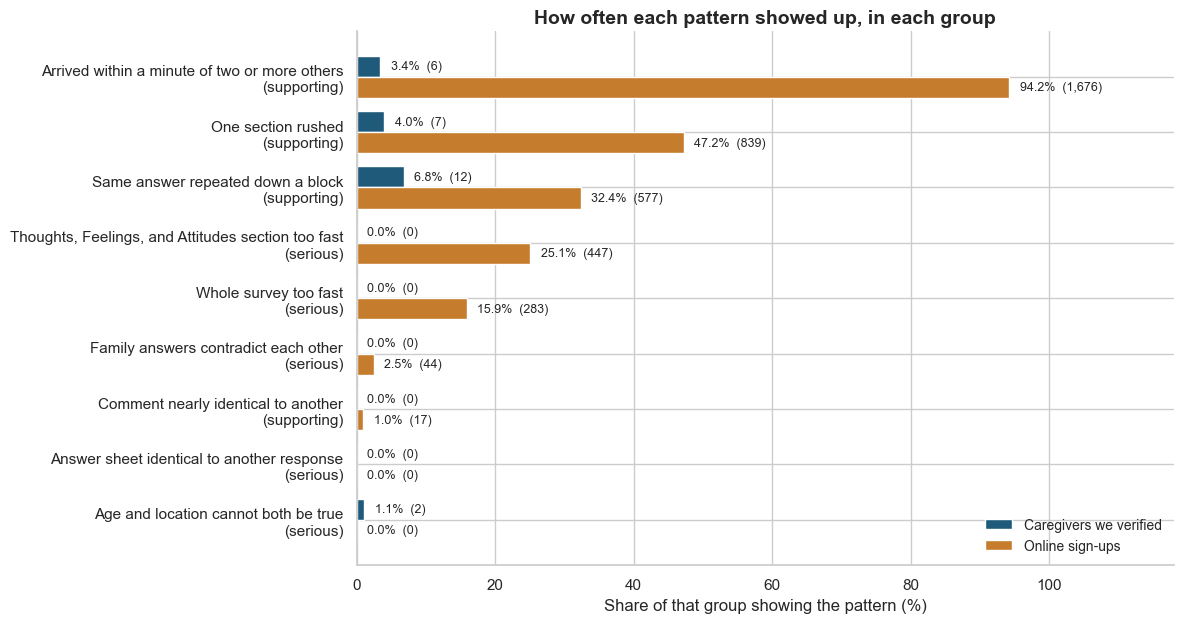

In [13]:
display(ba.build_all_checks_frequency_table(screen_inputs))
ba.plot_all_checks_frequency(screen_inputs);

## 3.5 How many patterns landed on one response

A response with **zero** patterns looks like response 1779. **One** looks like 1243. **Two or more** starts to look like 1276, 1355, or 1026.

One caveat on the dashed line: 46 of the 177 verified caregivers did not finish all four sections, so the two whole-timing checks could never fire on them. The ceiling of two checks in the verified group is real, but it is not measured on an identical footing.

,Number of patterns on one response,Caregivers we verified,Caregivers we verified (% of group),Online sign-ups,Online sign-ups (% of group)
0,0,153,86.4,70,3.9
1,1,21,11.9,662,37.2
2,2,3,1.7,411,23.1
3,3,0,0.0,275,15.5
4,4,0,0.0,239,13.4
5,5,0,0.0,114,6.4
6,6,0,0.0,8,0.4


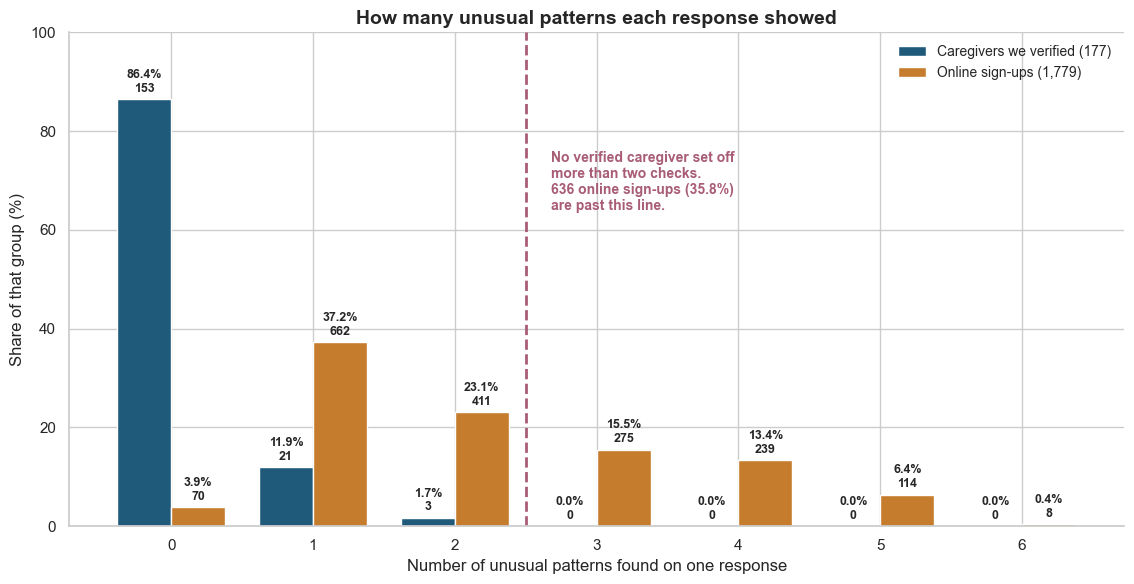

In [14]:
display(ba.build_checks_set_off_table(screen_inputs))
ba.plot_checks_set_off(screen_inputs);

## 3.6 How closely the sign-ups arrivedThe burst check asks how close together sign-ups arrived, so this chart measures the **gap between each sign-up and the one before it**. That is the quantity the check reads.A chart of sign-ups per day would not answer this. 100 verified caregivers also arrived on a single day, spread calmly across it, and a daily chart would make that look like the same behaviour. It is not.

,Gap to the sign-up before it,Caregivers we verified (count),Caregivers we verified (% of group),Online sign-ups (count),Online sign-ups (% of group)
0,Under 1 minute,25,14.2,1716,96.5
1,1 to 5 minutes,44,25.0,6,0.3
2,5 to 30 minutes,41,23.3,33,1.9
3,30 minutes or more,66,37.5,23,1.3


Middle gap between online sign-ups: 4 seconds.
Middle gap between verified caregivers: 10.6 minutes.
96.5% of online sign-ups arrived under a minute after the one before, against 14.2% of verified caregivers.


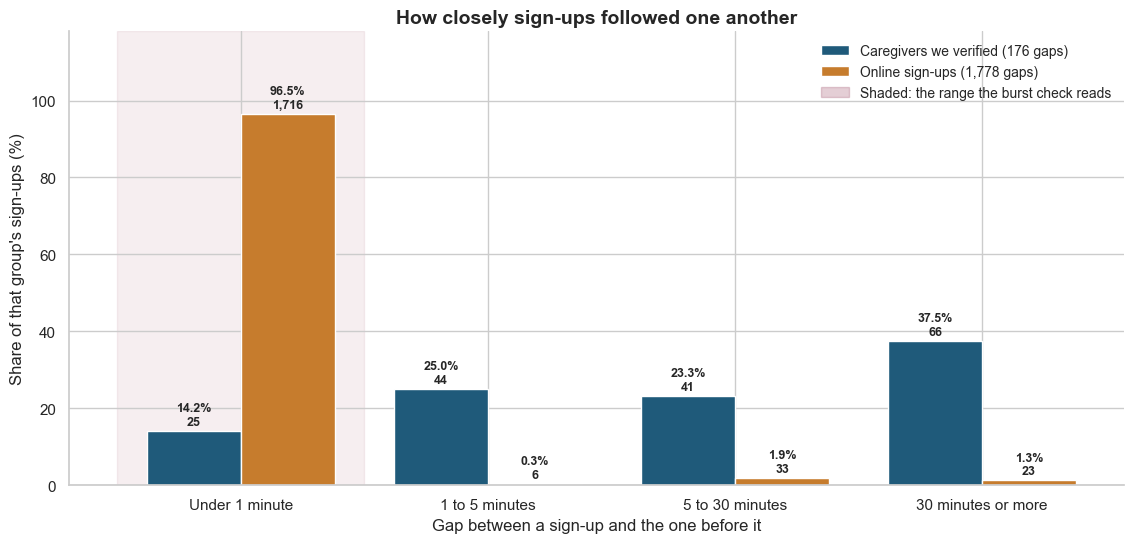

In [15]:
arrival = ba.build_arrival_tables(screen_inputs)
facts = arrival["surge_facts"]

display(arrival["gap_table"])

print(
    f"Middle gap between online sign-ups: {facts['median_gap_seconds']:.0f} seconds.\n"
    f"Middle gap between verified caregivers: {facts['verified_median_gap_minutes']:.1f} minutes.\n"
    f"{facts['online_under_minute_pct']:.1f}% of online sign-ups arrived under a minute after the one "
    f"before, against {facts['verified_under_minute_pct']:.1f}% of verified caregivers."
)
ba.plot_arrival_pattern(screen_inputs);

### What the surge day produced

The three days before the surge hold only 57 responses, so treat them as a small comparison group.

In [16]:
display(arrival["surge_crosstab"])
print(
    f"On {facts['surge_day']:%d %b %Y}, {facts['surge_n']:,} of the {facts['online_n']:,} online "
    f"sign-ups arrived, {facts['busiest_n']:,} of them inside four hours."
)

Payment Decision,When it arrived,Responses,Cleared for payment now,Low-risk provisional approval,Needs human review,Confirmed bot / reject
0,The three days before it,57,36,10,11,0
1,Surge day (06 Sep),1722,34,650,1032,6


On 06 Sep 2025, 1,722 of the 1,779 online sign-ups arrived, 1,717 of them inside four hours.


---
# 4. What the rule produced, and what it misses

## 4.1 The payment groups

In [17]:
display(action_summary)
display(timing_summary)
display(study_action_summary)

,Action group,Records,Share of all responses,What to do
0,Pay now,223,11.4%,Send gift card now
1,Low-risk approval,679,34.7%,Approve after quick check
2,Review,1048,53.6%,Hold for human review
3,Do not pay,6,0.3%,Do not pay


,Action group,Study 2 records,Median full survey time,Median attitudes time
0,Pay now,70,35.54 min,23.35 min
1,Low-risk approval,660,30.23 min,19.65 min
2,Review,1043,15.25 min,8.52 min
3,Do not pay,6,9.63 min,4.40 min


,Study,Action group,Records,Share within study (%),What to do
0,Study 1 - verified caregiver sample,Pay now,153,86.4,Send gift card now
1,Study 1 - verified caregiver sample,Low-risk approval,19,10.7,Approve after quick check
2,Study 1 - verified caregiver sample,Review,5,2.8,Hold for human review
3,Study 1 - verified caregiver sample,Do not pay,0,0.0,Do not pay
4,Study 2 - online recruitment sample,Pay now,70,3.9,Send gift card now
5,Study 2 - online recruitment sample,Low-risk approval,660,37.1,Approve after quick check
6,Study 2 - online recruitment sample,Review,1043,58.6,Hold for human review
7,Study 2 - online recruitment sample,Do not pay,6,0.3,Do not pay


The median times above describe the responses inside each payment group. They are not the lines. The lines are the stricter verified caregiver values shown in section 1.

## 4.2 How heavy is the hold pile

Some held responses have only timing or arrival concerns. Others combine timing with Family Information or answer-pattern problems.

In [18]:
display(hold_pile_mix)

,Pattern inside the Study 2 hold pile,Records,Share of hold pile (%),How to read it
0,Timing or arrival only,560,53.4,No strong contradiction; these were held because milder timing or arrival patterns pil...
1,One strong questionnaire concern,207,19.7,"One stronger issue is present, but not enough on its own for a do-not-pay decision."
2,Two strong concerns,279,26.6,Two stronger issues show up on the same record; this is the clearest part of the hold ...
3,Three or more strong concerns,3,0.3,Very concentrated concern; this is the strongest end of the hold pile.


## 4.3 What is driving the holds

Three numbers per pattern, drawn side by side because they overlap: one response can be counted in more than one of them.

Arrival timing is the single biggest driver. Switching it off would release 400 responses, so it is worth confirming this is meant as a payment rule and not just background context.

,Pattern,Where it shows up,How seriously we treat it,Online sign-ups showing it,Times it was the only issue on the response,Responses released if we removed it
0,Arrived within a minute of two or more others,Response arrival time,Supporting,1676,641,400
1,One section rushed,"Section timing across Family Information, Values, Thoughts/Feelings/Attitudes, or Demo...",Supporting,839,6,216
2,Same answer repeated down a block,Repeated ratings within a survey block,Supporting,577,13,189
3,"Thoughts, Feelings, and Attitudes section too fast","Thoughts, Feelings, and Attitudes timing",Serious,447,0,0
4,Whole survey too fast,Whole survey timing,Serious,283,0,1
5,Family answers contradict each other,Family Information,Serious,44,2,9
6,Comment nearly identical to another,Open-text comment,Supporting,17,0,1


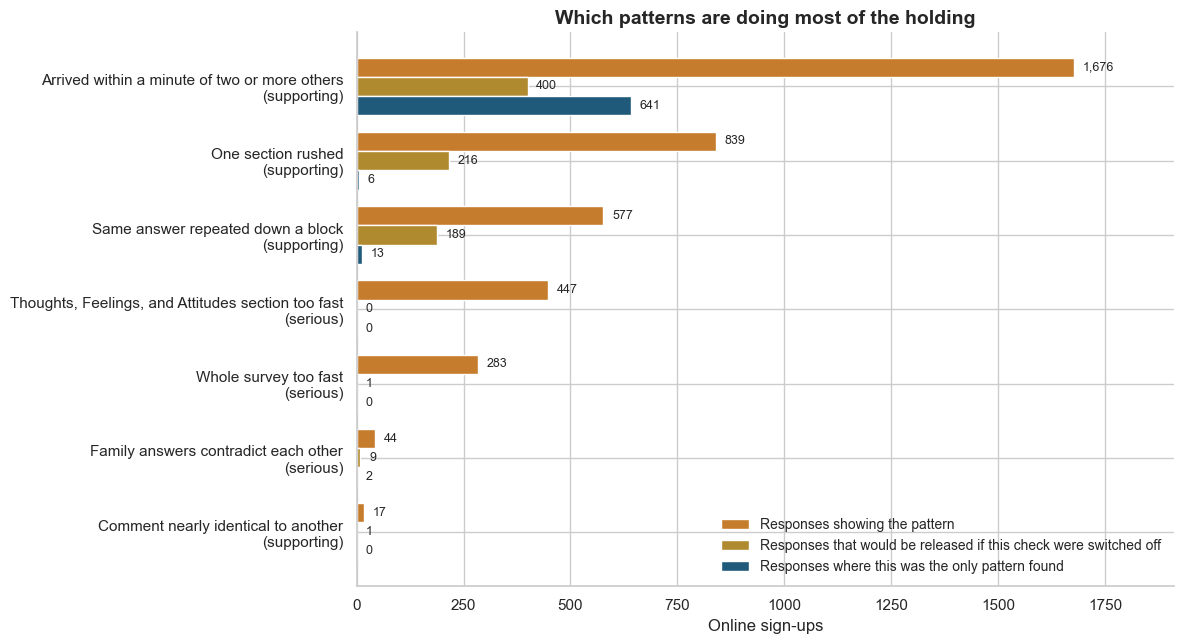

In [19]:
check_impact = ba.build_check_impact_table(screen_inputs)
display(check_impact)
ba.plot_check_impact(check_impact);

## 4.4 Where the timing checks cannot reachEvery timing check needs a recorded time. A blank or half-started form slips past all of them unless something else in the answers contradicts.Watch the bottom row: 111 responses cleared the sign-up screen and then left the survey blank. All 111 were approved to pay. No timing rule can reach them, because there is no timed section to compare.

In [20]:
display(ba.build_timing_coverage_table(screen_inputs))

,What we were able to time,Responses,Approved to pay,Held for review or rejected
0,All four sections timed,1575,574,1001
1,"Some sections timed, attitudes section missing",81,40,41
2,"Some sections timed, one other section missing",12,5,7
3,No timing at all,111,111,0


## 4.5 Where to start, and what it costsThe hold pile is worked worst first here, at a planning assumption of 8 minutes per response.

In [21]:
display(ba.build_work_plan_table(screen_inputs, minutes_per_response=8))

,"Batch, worst first",Responses in this batch,Responses checked once this batch is done,"Responses that beat the fastest verified caregiver, found so far",Hours of staff time at 8 minutes each,Responses still unchecked
0,Set off 5 or 6 checks,117,117,117 of 445,16,926
1,Set off 4 checks,238,355,353 of 445,47,688
2,Set off 3 checks,275,630,444 of 445,84,413
3,Set off 2 checks or fewer,413,1043,445 of 445,139,0


Working the most concerning part of the pile first reaches almost every response that finished faster than the verified sample. The rest are not cleared. They need a different kind of review.

---
# 5. Excel export

This rebuilds the workbook from the same tables shown above, so the notebook and the spreadsheet cannot drift apart.

In [22]:
report_workbook = ba.export_simple_excel(
    output_dir=output_dir,
    cache_dir=cache_dir,
    excel_filename="ESD_Bot_Analysis_Simple_Summary.xlsx",
)
print(f"Workbook written: {report_workbook.name}")
print(pd.ExcelFile(report_workbook).sheet_names)

Workbook written: ESD_Bot_Analysis_Simple_Summary.xlsx
['Summary', 'Pay Now', 'Review Queue', 'Screen Guide', 'Extra Views']


---
# What the numbers say

**The timing lines are defensible.** Every one was recomputed from the raw answers in section 1.3 and matched. The online sample contains many more responses below those lines than the verified sample does, which contains none.

**The clearest warning signs are very fast timing, burst arrival, and Family Information contradictions.** Response 1355 shows timing alone pushing a response into review. Response 1026 shows timing plus a Family Information contradiction plus low-variation ratings producing the strongest concern. Response 296 answered 2 to all eleven questions in one rating block.

**Burst arrival is the biggest operational choice.** 94.2% of online sign-ups arrived within a minute of another sign-up, against 3.4% of verified caregivers, so the signal is real. But it is also the single largest driver of holds, and its 60-second window was the one line not read off the verified caregivers.

**The biggest gap is incomplete forms.** 111 responses were approved to pay without a single timed section. A completion rule is needed before any payment goes out.

**One check needs review before it is trusted.** Age and location cannot both be true has fired twice, both times on verified caregivers, and never on an online sign-up.